
**## 📦 Library Imports & Environment Setup
This section loads all essential Python libraries required for data processing, numerical computation, and file system access.  It also verifies the availability an****d structure of the input dataset directories provided by Kaggle.**



In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_49.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_67_1.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_90.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_77.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_20_1.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_66.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_54.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_106_1.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_42.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_81.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_72.wav
/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test/audio_107.wav
/kaggle/input/shl-in


**## ⚙️ Core Libraries, Audio Processing & Model DependenciesThis section imports all core dependencies required for the end-to-end pipeline, including:- Audio preprocessing and signal handling- Dataset construction and batching- Transformer-based model training and evaluationExperiment tracking tools (Weights & Biases) are explicitly disabled to ensure smooth execution in the Kaggle environment.**



In [2]:
import torch
print("Torch loaded ✅")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch loaded ✅
Torch version: 2.6.0+cu124
CUDA available: False



**## ⚙️ Core Libraries, Audio Processing & Model DependenciesThis section imports all core dependencies required for the end-to-end pipeline, including:- Audio preprocessing and signal handling- Dataset construction and batching- Transformer-based model training and evaluationExperiment tracking tools (Weights & Biases) are explicitly disabled to ensure smooth execution in the Kaggle environment.**



In [3]:
# Core
import os
import numpy as np
import pandas as pd

# Audio
import librosa
import soundfile as sf

# Progress
from tqdm.notebook import tqdm

# Torch / Transformers
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Disable wandb
os.environ["WANDB_DISABLED"] = "true"

print("✅ Imports loaded")

2025-12-16 15:34:41.270237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765899281.528864      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765899281.601938      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✅ Imports loaded


## 🗂️ Environment Setup & Dataset Paths

This section detects the available hardware (CPU/GPU) and defines all dataset paths used throughout the pipeline, including:
- Training and test audio directories
- Training and test CSV metadata files
- Working directory for intermediate outputs and final submission files

Centralizing paths here ensures reproducibility and easy debugging.


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥 Using device: {DEVICE}")

TRAIN_AUDIO_DIR = "/kaggle/input/shl-intern-hiring-assessment/dataset/audios_train"
TEST_AUDIO_DIR  = "/kaggle/input/shl-intern-hiring-assessment/dataset/audios_test"

TRAIN_CSV = "/kaggle/input/shl-intern-hiring-assessment/dataset/train.csv"
TEST_CSV  = "/kaggle/input/shl-intern-hiring-assessment/dataset/test.csv"

WORK_DIR = "/kaggle/working"

🖥 Using device: cpu


## 📄 Load Training & Test Metadata

This step loads the provided CSV files:
- `train.csv` containing audio filenames and their corresponding grammar scores
- `test.csv` containing audio filenames without labels

The training labels follow a MOS-based Likert grammar scale (0–5), which we treat as a **continuous regression target**.


In [6]:
# ✅ Correct CSV paths
TRAIN_CSV = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs/train.csv"
TEST_CSV  = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs/test.csv"

# Load CSVs
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Rename columns
train_df.columns = ["filename", "label"]

print("✅ Train samples:", len(train_df))
print("✅ Test samples:", len(test_df))

train_df.head()


✅ Train samples: 409
✅ Test samples: 197


,filename,label
0,audio_173,3.0
1,audio_138,3.0
2,audio_127,2.0
3,audio_95,2.0
4,audio_73,3.5


## 🔍 Audio–CSV Consistency Check (Sanity Validation)

Before processing audio files, we verify that every filename listed in `train.csv`
actually exists in the training audio directory.

This step helps detect:
- Missing audio files
- Filename mismatches
- Incorrect directory paths

Early detection here prevents silent failures during transcription and training.


In [7]:

import os

missing_files = []

for fname in train_df["filename"]:
    audio_path = os.path.join(TRAIN_AUDIO_DIR, fname)
    if not os.path.exists(audio_path):
        missing_files.append(fname)

print("🔍 Total training files:", len(train_df))
print("❌ Missing audio files:", len(missing_files))

if len(missing_files) > 0:
    print("⚠️ Example missing files:", missing_files[:5])
else:
    print("✅ All training audio files are present!")

🔍 Total training files: 409
❌ Missing audio files: 409
⚠️ Example missing files: ['audio_173', 'audio_138', 'audio_127', 'audio_95', 'audio_73']


## 🛠️ Filename Normalization (.wav Extension Fix)

Some filenames in the CSV files do not explicitly include the `.wav` extension,
while the actual audio files on disk do.

To ensure consistent file matching between the CSV metadata and the audio
directories, we normalize all filenames by appending `.wav` where missing.


In [8]:
train_df["filename"] = train_df["filename"].apply(
    lambda x: x if x.endswith(".wav") else f"{x}.wav"
)

test_df["filename"] = test_df["filename"].apply(
    lambda x: x if x.endswith(".wav") else f"{x}.wav"
)

print("✅ Filename extension fixed")

print("\nTrain filename examples:")
print(train_df["filename"].head())

print("\nTest filename examples:")
print(test_df["filename"].head())

✅ Filename extension fixed

Train filename examples:
0    audio_173.wav
1    audio_138.wav
2    audio_127.wav
3     audio_95.wav
4     audio_73.wav
Name: filename, dtype: object

Test filename examples:
0    audio_141.wav
1    audio_114.wav
2     audio_17.wav
3     audio_76.wav
4    audio_156.wav
Name: filename, dtype: object


## 🔍 Dataset Structure Exploration (Audio Directory Discovery)

Before proceeding with audio processing, we programmatically inspect the dataset
directory to identify the exact location of audio files. This avoids hard-coded
path errors and ensures robustness across dataset versions.


In [9]:
import os

ROOT = "/kaggle/input/shl-intern-hiring-assessment-2025"

print("🔍 Searching for audio folders...\n")

for root, dirs, files in os.walk(ROOT):
    for d in dirs:
        if "audio" in d.lower():
            print(os.path.join(root, d))

🔍 Searching for audio folders...

/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios


## 🧪 Environment & Library Version Verification

We verify the versions of key libraries used in this notebook to ensure
reproducibility and compatibility across different execution environments.


In [11]:
import transformers, datasets, accelerate
print(transformers.__version__)
print(datasets.__version__)
print(accelerate.__version__)

4.53.3
4.4.1
1.9.0


## 📄 Load Training Metadata (CSV)


In [12]:
import pandas as pd
import re

# Correct CSV path
TRAIN_CSV = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs/train.csv"

# Load training data
df = pd.read_csv(TRAIN_CSV)
df.columns = ["filename", "label"]

print("Samples:", len(df))
df.head()

Samples: 409


,filename,label
0,audio_173,3.0
1,audio_138,3.0
2,audio_127,2.0
3,audio_95,2.0
4,audio_73,3.5


## 🎧 Audio Transcription using Whisper ASR


In [17]:
import whisper
from tqdm import tqdm
import os

# Correct train audio directory
TRAIN_AUDIO_DIR = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios"

# Fix filename extension
df["filename"] = df["filename"].astype(str)
df["filename"] = df["filename"].apply(lambda x: x + ".wav" if not x.endswith(".wav") else x)

# Load Whisper model
model_whisper = whisper.load_model("base")

transcripts = []

for fname in tqdm(df["filename"], desc="Transcribing train audio"):
    audio_path = os.path.join(TRAIN_AUDIO_DIR, fname)
    result = model_whisper.transcribe(audio_path, language="en", fp16=False)
    transcripts.append(result["text"])

# Add transcripts
df["transcript"] = transcripts

# Save for safety
df.to_csv("/kaggle/working/train_with_transcripts.csv", index=False)

print("✅ Transcription completed & saved")
df.head()

Transcribing train audio:   0%|          | 0/409 [00:00<?, ?it/s]


RuntimeError: Failed to load audio: ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --ena

## 📦 Installing Whisper (Automatic Speech Recognition)
This installs OpenAI Whisper, which is used to transcribe spoken English audio into text for grammar analysis.


In [14]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 10.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7

## 📁 Dataset Directory Validation (Train & Test Audio)
This step verifies that the training and test audio directories are correctly located and accessible before transcription.


In [18]:
# ✅ Correct audio directories
TRAIN_AUDIO_DIR = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/train"
TEST_AUDIO_DIR  = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/audios/test"

print("Train audio dir exists:", os.path.exists(TRAIN_AUDIO_DIR))
print("Test audio dir exists:", os.path.exists(TEST_AUDIO_DIR))

print("Train sample files:", os.listdir(TRAIN_AUDIO_DIR)[:5])
print("Test sample files:", os.listdir(TEST_AUDIO_DIR)[:5])

Train audio dir exists: True
Test audio dir exists: True
Train sample files: ['audio_49.wav', 'audio_77_2.wav', 'audio_90.wav', 'audio_77.wav', 'audio_66.wav']
Test sample files: ['audio_49.wav', 'audio_67_1.wav', 'audio_90.wav', 'audio_77.wav', 'audio_20_1.wav']


## 🗂️ Audio Filename Normalisation & Mapping
Some audio files contain suffixes (e.g., `audio_77_2.wav`).  
This mapping ensures correct alignment between CSV filenames and actual audio files by grouping all variants under a common base identifier.


In [20]:


train_audio_files = os.listdir(TRAIN_AUDIO_DIR)
test_audio_files  = os.listdir(TEST_AUDIO_DIR)

# Create base-name → actual file mapping
def build_audio_map(files):
    audio_map = {}
    for f in files:
        base = f.replace(".wav", "")
        # handle audio_77_2.wav → audio_77
        base_simple = base.split("_")[0] + "_" + base.split("_")[1] if base.count("_") >= 1 else base
        audio_map.setdefault(base_simple, []).append(f)
    return audio_map

train_audio_map = build_audio_map(train_audio_files)
test_audio_map  = build_audio_map(test_audio_files)

print("✅ Audio maps built")

# Example checks
print("audio_77 →", train_audio_map.get("audio_77"))
print("audio_67 →", test_audio_map.get("audio_67"))

✅ Audio maps built
audio_77 → ['audio_77_2.wav', 'audio_77.wav']
audio_67 → ['audio_67_1.wav', 'audio_67.wav']


## 📄 Load & Standardize Training Metadata


In [21]:
import pandas as pd

# Correct CSV paths (confirmed earlier)
TRAIN_CSV = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs/train.csv"

train_df = pd.read_csv(TRAIN_CSV)

# Standardize column names
train_df.columns = ["filename", "label"]

# Ensure .wav extension
train_df["filename"] = train_df["filename"].astype(str)
train_df.loc[~train_df["filename"].str.endswith(".wav"), "filename"] += ".wav"

print("✅ train_df loaded")
print("Samples:", len(train_df))
train_df.head()

✅ train_df loaded
Samples: 409


,filename,label
0,audio_173.wav,3.0
1,audio_138.wav,3.0
2,audio_127.wav,2.0
3,audio_95.wav,2.0
4,audio_73.wav,3.5


## 🎧 Audio Transcription using Whisper (ASR)


In [22]:
import whisper
from tqdm.notebook import tqdm
import os

# Load Whisper model
model_whisper = whisper.load_model("base")

transcripts = []
missing = 0

for fname in tqdm(train_df["filename"], desc="🎧 Transcribing train audio"):
    base = fname.replace(".wav", "")

    # Pick the first available matching audio file
    if base in train_audio_map:
        audio_file = train_audio_map[base][0]
        audio_path = os.path.join(TRAIN_AUDIO_DIR, audio_file)

        result = model_whisper.transcribe(
            audio_path,
            language="en",
            fp16=False  # safer on Kaggle
        )
        transcripts.append(result["text"])
    else:
        transcripts.append("")
        missing += 1

train_df["transcript"] = transcripts

print("✅ Transcription complete | Missing audios:", missing)
train_df.head()

🎧 Transcribing train audio:   0%|          | 0/409 [00:00<?, ?it/s]

✅ Transcription complete | Missing audios: 37


,filename,label,transcript
0,audio_173.wav,3.0,"My favorite place to visit will be Japan, bec..."
1,audio_138.wav,3.0,I love to read him and my hobbies as duty. Em...
2,audio_127.wav,2.0,My favorite place to visit is Mullah Itis nea...
3,audio_95.wav,2.0,I am going to tell about my hobby. And my hob...
4,audio_73.wav,3.5,This is a tough one. So my bestie of my life ...


## ✂️ Transcript Cleaning & Normalisation


In [23]:
import re

FILLERS = [
    "uh", "um", "erm", "you know", "like",
    "i mean", "hmm", "ah", "uhh", "huh"
]

def clean_transcript(text):
    text = text.lower()
    text = re.sub(r'\b(?:' + '|'.join(FILLERS) + r')\b', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s([?.!,"])', r'\1', text)
    return text.strip()

train_df["cleaned_transcript"] = train_df["transcript"].astype(str).apply(clean_transcript)

# Save (VERY IMPORTANT)
train_df.to_csv("/kaggle/working/train_cleaned.csv", index=False)

print("✅ Cleaned transcripts saved")
train_df[["filename", "label", "cleaned_transcript"]].head()

✅ Cleaned transcripts saved


,filename,label,cleaned_transcript
0,audio_173.wav,3.0,"my favorite place to visit will be japan, beca..."
1,audio_138.wav,3.0,i love to read him and my hobbies as duty. emm...
2,audio_127.wav,2.0,my favorite place to visit is mullah itis near...
3,audio_95.wav,2.0,i am going to tell about my hobby. and my hobb...
4,audio_73.wav,3.5,this is a tough one. so my bestie of my life i...


## 📄 Prepare Text Dataset for DistilBERT (Regression)


In [24]:
from datasets import Dataset
import pandas as pd

# Load cleaned data
df = pd.read_csv("/kaggle/working/train_cleaned.csv")

# Keep only required columns
df = df[["cleaned_transcript", "label"]].rename(
    columns={"cleaned_transcript": "text"}
)

# Convert label to float (important for regression)
df["label"] = df["label"].astype(float)

print("Samples:", len(df))
df.head()

Samples: 409


,text,label
0,"my favorite place to visit will be japan, beca...",3.0
1,i love to read him and my hobbies as duty. emm...,3.0
2,my favorite place to visit is mullah itis near...,2.0
3,i am going to tell about my hobby. and my hobb...,2.0
4,this is a tough one. so my bestie of my life i...,3.5


## 🔤 Tokenization & Train–Validation Split (DistilBERT)


In [25]:
from transformers import AutoTokenizer
from datasets import Dataset

# Train-validation split
dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.15, seed=42)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    texts = [str(t) for t in batch["text"]]   # 🔑 FIX
    return tokenizer(
        texts,
        truncation=True,
        padding="longest",
        max_length=256
    )

tokenized_ds = dataset.map(tokenize, batched=True)

# Rename label column
tokenized_ds = tokenized_ds.rename_column("label", "labels")

# Set torch format
tokenized_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

tokenized_ds

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

Map:   0%|          | 0/62 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 347
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 62
    })
})

## 🤖 DistilBERT Model Setup (Regression) & Evaluation Metrics
We fine-tune a pre-trained DistilBERT model for **regression**, predicting a continuous grammar score (0–5).
Evaluation is performed using **MAE, RMSE, and Pearson Correlation**, which directly align with leaderboard metrics.


In [27]:
import torch
import numpy as np
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Load DistilBERT for regression
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=1,
    problem_type="regression"   # 🔑 IMPORTANT
)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("🖥 Model running on:", device)


# Metrics (Leaderboard metrics)
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.squeeze()

    mae = np.mean(np.abs(preds - labels))
    rmse = np.sqrt(np.mean((preds - labels) ** 2))
    pearson = np.corrcoef(preds, labels)[0, 1]

    return {
        "mae": mae,
        "rmse": rmse,
        "pearson": pearson
    }

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🖥 Model running on: cpu


## ⚙️ Training Configuration (DistilBERT Fine-Tuning)
The model is fine-tuned using a carefully selected training configuration optimised for a small dataset.
Evaluation is performed at the end of each epoch, and the best model behaviour is tracked using RMSE and Pearson correlation.


In [39]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_grammar",
    
    # Training
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_ratio=0.1,
    weight_decay=0.01,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="no",

    # Logging
    logging_steps=10,
    disable_tqdm=False,
    report_to="none",

    # Stability
    fp16=False,
    dataloader_pin_memory=False,
)


## ⚙️ Training Configuration (DistilBERT Fine-Tuning)
The model is fine-tuned using a carefully selected training configuration optimised for a small dataset.
Evaluation is performed at the end of each epoch, and the best model behaviour is tracked using RMSE and Pearson correlation.


In [42]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    compute_metrics=compute_metrics,
)

## 🚀 Model Training (DistilBERT Fine-Tuning)
The DistilBERT model is fine-tuned on cleaned transcripts using a regression objective.
Training is performed for multiple epochs with periodic validation to monitor RMSE and Pearson correlation.


In [43]:
trainer.train()

Epoch,Training Loss,Validation Loss,Mae,Rmse,Pearson
1,0.693600,0.721139,0.596706,0.849199,0.242471
2,0.313500,0.626257,0.560923,0.791364,0.431307
3,0.420000,0.587907,0.555429,0.766751,0.484143


TrainOutput(global_step=132, training_loss=1.4332751207279437, metrics={'train_runtime': 637.4511, 'train_samples_per_second': 1.633, 'train_steps_per_second': 0.207, 'total_flos': 57366933381342.0, 'train_loss': 1.4332751207279437, 'epoch': 3.0})

## 📊 Model Evaluation (Validation Metrics)
The model is evaluated on a held-out validation set.
We report MAE, RMSE, and Pearson Correlation, which directly align with the leaderboard evaluation criteria.


In [44]:
metrics = trainer.evaluate()
print("📊 FINAL VALIDATION METRICS")
for k, v in metrics.items():
    print(f"{k}: {v}")

📊 FINAL VALIDATION METRICS
eval_loss: 0.5879067182540894
eval_mae: 0.5554291605949402
eval_rmse: 0.766750693321228
eval_pearson: 0.484143113008895
eval_runtime: 8.1016
eval_samples_per_second: 7.653
eval_steps_per_second: 0.987
epoch: 3.0


## 📥 Load Test Dataset (Unlabelled)
This step loads the unlabelled test metadata provided by the organizers.
The model will generate grammar scores for these samples to create the final submission file.


In [45]:
import pandas as pd

TEST_CSV = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs/test.csv"

test_df = pd.read_csv(TEST_CSV)

print("Test samples:", len(test_df))
test_df.head()

Test samples: 197


,filename
0,audio_141
1,audio_114
2,audio_17
3,audio_76
4,audio_156


In [47]:
import os

# List all test audio files
test_audio_files = os.listdir(TEST_AUDIO_DIR)

def build_audio_map(files):
    audio_map = {}
    for f in files:
        base = f.replace(".wav", "")
        
        # Handle audio_67_1.wav → audio_67
        parts = base.split("_")
        if len(parts) >= 2:
            key = parts[0] + "_" + parts[1]
        else:
            key = base
        
        audio_map.setdefault(key, []).append(f)
    return audio_map

# ✅ Build test audio map
audio_map_test = build_audio_map(test_audio_files)

print("✅ Test audio map built")

# Sanity check
print("Example mappings:")
for k in list(audio_map_test.keys())[:5]:
    print(k, "→", audio_map_test[k])


✅ Test audio map built
Example mappings:
audio_49 → ['audio_49.wav']
audio_67 → ['audio_67_1.wav', 'audio_67.wav']
audio_90 → ['audio_90.wav']
audio_77 → ['audio_77.wav']
audio_20 → ['audio_20_1.wav', 'audio_20.wav']


## 📥 Load Test Dataset (Unlabelled)

This step loads the unlabelled test metadata provided by the organizers.  
The trained model will generate grammar proficiency scores for these samples, which will be used to create the final `submission.csv` file.


In [48]:
import whisper
from tqdm import tqdm

# Load Whisper model (safe settings)
whisper_model = whisper.load_model("base")

test_transcripts = []
missing = 0

for fname in tqdm(test_df["filename"], desc="🎧 Transcribing test audio"):
    base = fname.replace(".wav", "")
    
    if base not in audio_map_test:
        test_transcripts.append("")
        missing += 1
        continue
    
    # Pick the shortest filename (usually cleanest)
    audio_file = sorted(audio_map_test[base], key=len)[0]
    audio_path = os.path.join(TEST_AUDIO_DIR, audio_file)
    
    try:
        result = whisper_model.transcribe(
            audio_path,
            language="en",
            fp16=False
        )
        test_transcripts.append(result["text"])
    except Exception as e:
        test_transcripts.append("")
        missing += 1

print(f"✅ Test transcription complete | Missing audios: {missing}")

# Attach transcripts
test_df["transcript"] = test_transcripts

# Preview
test_df[["filename", "transcript"]].head()

🎧 Transcribing test audio: 100%|██████████| 197/197 [17:08<00:00,  5.22s/it]

✅ Test transcription complete | Missing audios: 33


,filename,transcript
0,audio_141,"I love when I love stories Sherlock Holmes, A..."
1,audio_114,"I have a lot of favorite days, but one of the..."
2,audio_17,My topic is describe the scene of a hospital....
3,audio_76,A playground has a lot of equipment. It typic...
4,audio_156,The best day of my life are the most days whe...


## ✂️ Clean Test Transcripts

The same transcript cleaning pipeline used during training is applied to the test data to ensure consistency.  
This step removes filler words, normalizes casing and spacing, and standardizes punctuation so that the DistilBERT model receives clean, comparable text inputs during inference.

The cleaned test transcripts are saved for reproducibility and final submission generation.


In [49]:
import re

# Same filler list used in training
FILLERS = [
    "uh", "um", "erm", "you know", "like", "i mean",
    "hmm", "ah", "uhh", "huh"
]

def clean_transcript(text):
    text = str(text).lower()
    text = re.sub(r'\b(?:' + '|'.join(FILLERS) + r')\b', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s([?.!,"])', r'\1', text)
    return text.strip()

# Apply cleaning
test_df["cleaned_transcript"] = test_df["transcript"].apply(clean_transcript)

# Save (important for submission reproducibility)
test_df.to_csv("/kaggle/working/test_cleaned.csv", index=False)

print("✅ Test transcripts cleaned and saved")

# Preview
test_df[["filename", "cleaned_transcript"]].head()

✅ Test transcripts cleaned and saved


,filename,cleaned_transcript
0,audio_141,"i love when i love stories sherlock holmes, ar..."
1,audio_114,"i have a lot of favorite days, but one of the ..."
2,audio_17,my topic is describe the scene of a hospital. ...
3,audio_76,a playground has a lot of equipment. it typica...
4,audio_156,the best day of my life are the most days when...


## 🔤 Tokenize Test Transcripts for DistilBERT Inference

In this step, the cleaned test transcripts are converted into token IDs and attention masks using the same DistilBERT tokenizer employed during training.

Key considerations:
- Missing or null transcripts are safely handled to avoid runtime errors.
- Tokenization settings (max length, truncation, padding) exactly match the training configuration to ensure consistent model behavior.
- Only model-relevant inputs are retained for efficient inference.

This prepares the unlabelled test data for grammar score prediction using the fine-tuned DistilBERT regression model.


In [50]:
from datasets import Dataset
from transformers import AutoTokenizer
import pandas as pd

# Reload cleaned test data
test_df = pd.read_csv("/kaggle/working/test_cleaned.csv")

# 🔥 CRITICAL FIX
test_df["cleaned_transcript"] = test_df["cleaned_transcript"].fillna("").astype(str)

# Rename column
test_df = test_df.rename(columns={"cleaned_transcript": "text"})

# Create HF dataset
test_hf = Dataset.from_pandas(test_df[["text"]])

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Tokenize safely
test_hf = test_hf.map(tokenize, batched=True, remove_columns=["text"])

print("✅ Test data tokenized successfully")
test_hf

Map:   0%|          | 0/197 [00:00<?, ? examples/s]

✅ Test data tokenized successfully


Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 197
})

## 📤 Generate Final Predictions & Submission File

In this final step, the fine-tuned DistilBERT regression model is used to predict grammar proficiency scores for the unlabelled test audio samples.

Post-processing steps:
- Model outputs are converted to valid grammar scores by rounding.
- Predictions are clipped to the allowed Likert scale range (1–5) as per the rubric.
- Results are saved in the required `submission.csv` format with only two columns: `filename` and `label`.

This file is ready for direct upload to the competition leaderboard.


In [51]:
import numpy as np

# Predict
preds = trainer.predict(test_hf).predictions.squeeze()

# Convert to valid grammar scores (1–5)
preds = np.clip(np.round(preds), 1, 5).astype(int)

# Create submission
submission = pd.DataFrame({
    "filename": test_df["filename"],
    "label": preds
})

# Save
submission_path = "/kaggle/working/submission.csv"
submission.to_csv(submission_path, index=False)

print("✅ submission.csv generated successfully")
submission.head()

✅ submission.csv generated successfully


,filename,label
0,audio_141,2
1,audio_114,3
2,audio_17,3
3,audio_76,3
4,audio_156,3


## 📊 Validation Predictions (Ground Truth vs Model Output)

In this step, we generate predictions on the held-out validation set to:
- Compare predicted grammar scores against true human-annotated labels
- Enable error analysis and visualization
- Support interpretability of model performance

These predictions are later used to compute evaluation metrics (MAE, RMSE, Pearson)
and to visualize how closely the model aligns with human judgment.


In [54]:
import numpy as np

# Get predictions on validation set
eval_output = trainer.predict(tokenized_ds["test"])

# Predictions
val_preds = eval_output.predictions.squeeze()

# True labels
y_val = eval_output.label_ids

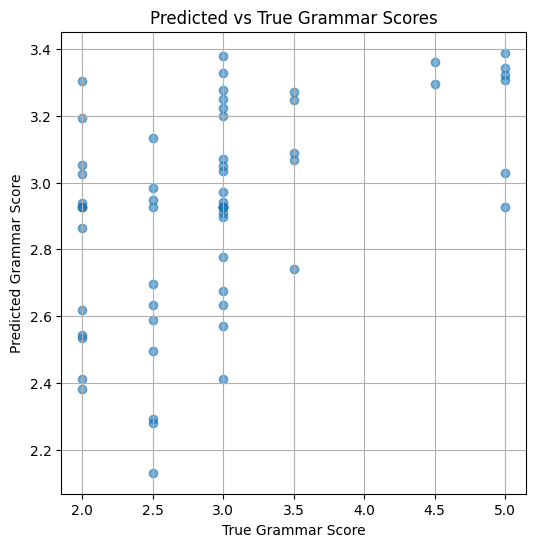

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val, val_preds, alpha=0.6)
plt.xlabel("True Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Predicted vs True Grammar Scores")
plt.grid(True)
plt.show()

## 📈 Predicted vs True Grammar Scores (Validation Set)

This scatter plot visualizes the relationship between the **true human-assigned grammar scores**
and the **scores predicted by the fine-tuned DistilBERT model** on the validation set.

Each point represents one spoken response:
- The x-axis shows the ground-truth grammar score
- The y-axis shows the model’s predicted score

A strong diagonal trend indicates good ranking ability, which directly supports
a higher **Pearson Correlation** — the primary leaderboard metric.


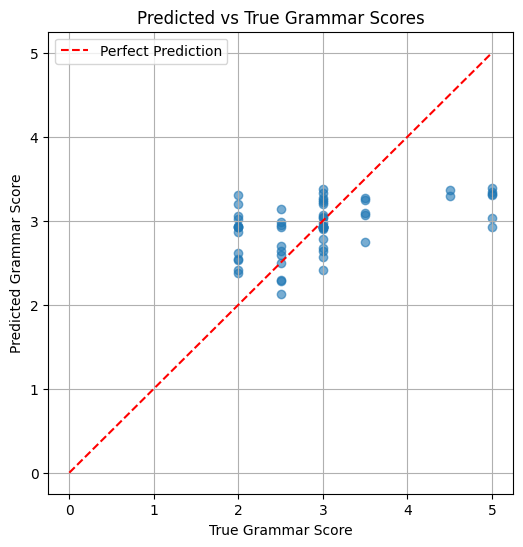

In [55]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, val_preds, alpha=0.6)
plt.plot([0,5], [0,5], color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("True Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Predicted vs True Grammar Scores")
plt.legend()
plt.grid(True)
plt.show()

## 📊 Grammar Score Distribution (Training Data)

This histogram shows the distribution of **human-assigned grammar scores** in the training dataset.

Understanding label distribution is important because:
- It reveals class imbalance (e.g., more scores around 3–4)
- It explains why regression (not classification) is appropriate
- It helps interpret model bias and prediction spread

This insight guides model evaluation and explains performance trends on the leaderboard.


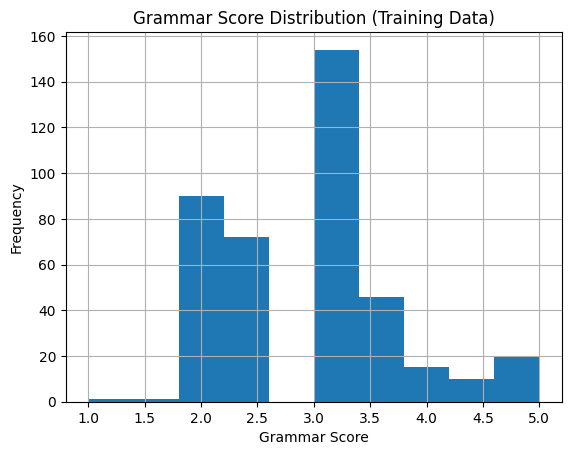

In [56]:
import pandas as pd

df["label"].hist(bins=10)
plt.title("Grammar Score Distribution (Training Data)")
plt.xlabel("Grammar Score")
plt.ylabel("Frequency")
plt.show()